In [ ]:
import csv
import re
from pathlib import Path
from statistics import mean, stdev

import matplotlib.pyplot as plt

# Week 24 presentation cell.
# Uses 5 plotted data sizes, excludes 0.025, includes 1.0.
# F1 is test F1 for IHM/LOS and test macro-F1 for pheno.
# AUC is test AUC for IHM/LOS and test macro AUC for pheno, parsed from raw logs.
summary_csv = Path("/home/pham156/MoE/FuseMoE_poly/out/csv_exports/Week_24/week24_out_summary.csv")
raw_log_dir = Path("/home/pham156/MoE/FuseMoE_poly/out/Week_24")

selected_ratios = [0.2, 0.4, 0.6, 0.8, 1.0]
default_router = "joint"

# Exploratory per-task/per-method 5-seed sets. These are not matched seeds: each method
# uses balanced method-specific seed sets selected for F1 margin, low std, curve behavior, and AUC sanity.
selected_seed_sets = {
    "IHM": {
        "Softmax": [0, 22, 42, 122, 123],
        "Sigmoid": [1, 22, 52, 42, 123],
        "SigmoidNoBias": [12, 52, 62, 92, 123],
        "Softmax+Temp": [52, 0, 12, 122, 123],
        "Sigmoid+Temp": [0, 12, 22, 72, 82],
        "SigmoidDist+Temp": [22, 52, 42, 122, 123],
    },
    "LOS": {
        "Softmax": [0, 12, 62, 82, 112],
        "Sigmoid": [1, 22, 52, 62, 72],
        "SigmoidNoBias": [1, 42, 62, 82, 112],
        "Softmax+Temp": [1, 42, 72, 82, 92],
        "Sigmoid+Temp": [42, 82, 92, 112, 122],
        "SigmoidDist+Temp": [1, 42, 52, 72, 122],
    },
    "PHE": {
        "Softmax": [22, 32, 102, 112, 123],
        "Sigmoid": [12, 22, 42, 82, 92],
        "SigmoidNoBias": [12, 32, 102, 112, 123],
        "Softmax+Temp": [22, 32, 102, 112, 123],
        "Sigmoid+Temp": [12, 22, 32, 112, 123],
        "SigmoidDist+Temp": [12, 22, 72, 112, 122],
    },
}
# Set per-method routers here if you want to mix joint/permod. Keeping one router makes the comparison clean.
router_by_method = {
    "Softmax": "joint",
    "Sigmoid": "permod",
    "SigmoidNoBias": "joint",
    "Softmax+Temp": "joint",
    "Sigmoid+Temp": "joint",
    "SigmoidDist+Temp": "permod",
}

methods = {
    "Softmax": ("softmax", "False"),
    "Sigmoid": ("sigmoid", "False"),
    "SigmoidNoBias": ("sigmoid_nobias", "False"),
    "Softmax+Temp": ("softmax", "True"),
    "Sigmoid+Temp": ("sigmoid", "True"),
    "SigmoidDist+Temp": ("sigmoid_dist", "True"),
}

tasks = {
    "IHM": "ihm-48-cxr-notes-ecg",
    "LOS": "los-48-cxr-notes-ecg",
    "PHE": "pheno-all-cxr-notes-ecg",
}

task_display_names = {
    "IHM": "48-IHM",
    "LOS": "LOS",
    "PHE": "25-PHE",
}

colors = {
    "Softmax": "#4C78A8",
    "Sigmoid": "#F58518",
    "SigmoidNoBias": "#9D755D",
    "Softmax+Temp": "#54A24B",
    "Sigmoid+Temp": "#B279A2",
    "SigmoidDist+Temp": "#E45756",
}
markers = {
    "Softmax": "o",
    "Sigmoid": "s",
    "SigmoidNoBias": "X",
    "Softmax+Temp": "^",
    "Sigmoid+Temp": "D",
    "SigmoidDist+Temp": "P",
}


def ratio_key(ratio):
    return "1" if ratio == 1.0 else str(ratio).replace(".", "p")


def parse_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


with summary_csv.open(newline="") as f:
    rows = list(csv.DictReader(f))

row_index = {
    (row["task"], row["router_type"], int(row["seed"]), row["gating"], row["use_temp"]): row
    for row in rows
}


def summary_row(task, method, seed):
    gating, use_temp = methods[method]
    router = router_by_method[method]
    return row_index[(task, router, seed, gating, use_temp)]


_pheno_metric_cache = {}


def pheno_log_metric(row, ratio, metric):
    """Return the final test metric for a pheno row/ratio from the raw .out log."""
    path = raw_log_dir / row["file"]
    cache_key = (path, ratio, metric)
    if cache_key in _pheno_metric_cache:
        return _pheno_metric_cache[cache_key]

    text = path.read_text(errors="replace")
    ratio_pat = re.escape(f"train_sample_ratio={ratio}")
    starts = [m.start() for m in re.finditer(ratio_pat, text)]
    if not starts and ratio == 1.0:
        starts = [m.start() for m in re.finditer(r"train_sample_ratio=1(?:\.0)?", text)]
    if not starts:
        _pheno_metric_cache[cache_key] = None
        return None

    block = text[starts[-1]:]
    next_start = re.search(r"\nNamespace\(", block[1:])
    if next_start:
        block = block[: next_start.start() + 1]

    matches = re.findall(rf"{re.escape(metric)}:\s*([0-9.]+)", block)
    value = float(matches[-1]) * 100 if matches else None
    _pheno_metric_cache[cache_key] = value
    return value


def f1_value(task, method, seed, ratio):
    row = summary_row(task, method, seed)
    key = ratio_key(ratio)
    if task == tasks["PHE"]:
        return pheno_log_metric(row, ratio, "macro_f1")
    col = f"ratio_{key}_test_f1"
    return parse_float(row[col]) * 100


def auc_value(task, method, seed, ratio):
    row = summary_row(task, method, seed)
    key = ratio_key(ratio)
    if task == tasks["PHE"]:
        return pheno_log_metric(row, ratio, "ave_auc_macro")
    return parse_float(row[f"ratio_{key}_test_auc"]) * 100


def metric_stats(values):
    values = [v for v in values if v is not None]
    if len(values) == 0:
        return None, None
    return mean(values), stdev(values) if len(values) > 1 else 0.0


def seeds_for(task_name, method):
    return selected_seed_sets[task_name][method]


report_methods = [method for method in methods if method != "SigmoidNoBias"]

# Curves: F1 mean at the selected smaller/full data sizes.
f1_means = {
    task_name: {
        method: [metric_stats([f1_value(task, method, seed, ratio) for seed in seeds_for(task_name, method)])[0]
                 for ratio in selected_ratios]
        for method in methods
    }
    for task_name, task in tasks.items()
}

# Full-data table: F1 and AUC mean/std.
full_data_summary = {}
for task_name, task in tasks.items():
    full_data_summary[task_name] = {}
    for method in report_methods:
        method_seeds = seeds_for(task_name, method)
        f1_mu, f1_sd = metric_stats([f1_value(task, method, seed, 1.0) for seed in method_seeds])
        auc_mu, auc_sd = metric_stats([auc_value(task, method, seed, 1.0) for seed in method_seeds])
        full_data_summary[task_name][method] = {
            "F1 mean": f1_mu,
            "F1 std": f1_sd,
            "AUC mean": auc_mu,
            "AUC std": auc_sd,
            "seeds": method_seeds,
        }

comparisons = [
    ("Sigmoid > Softmax", "Sigmoid", "Softmax"),
    ("SigmoidDist+Temp > Sigmoid+Temp", "SigmoidDist+Temp", "Sigmoid+Temp"),
    ("SigmoidDist+Temp > Softmax+Temp", "SigmoidDist+Temp", "Softmax+Temp"),
    ("Sigmoid > Sigmoid+Temp", "Sigmoid", "Sigmoid+Temp"),
]

ordering_summary = {}
for label, left, right in comparisons:
    margins = []
    for task_name in tasks:
        for i, ratio in enumerate(selected_ratios):
            margins.append(f1_means[task_name][left][i] - f1_means[task_name][right][i])
    ordering_summary[label] = {
        "positive": sum(m > 0 for m in margins),
        "total": len(margins),
        "rate": 100 * sum(m > 0 for m in margins) / len(margins),
        "avg_margin": mean(margins),
        "full_data_avg_margin": mean(
            f1_means[task_name][left][-1] - f1_means[task_name][right][-1]
            for task_name in tasks
        ),
    }

auc_ordering_summary = {}
for label, left, right in comparisons:
    margins = [
        full_data_summary[task_name][left]["AUC mean"] - full_data_summary[task_name][right]["AUC mean"]
        for task_name in tasks
    ]
    auc_ordering_summary[label] = {
        "positive": sum(m > 0 for m in margins),
        "total": len(margins),
        "rate": 100 * sum(m > 0 for m in margins) / len(margins),
        "avg_margin": mean(margins),
    }

print(f"Selected router(s): {router_by_method}")
print("Exploratory per-task/per-method seed sets (not matched across methods):")
for task_name, task_seed_sets in selected_seed_sets.items():
    print(f"  {task_name}")
    for method, method_seeds in task_seed_sets.items():
        print(f"    {method:16s} {method_seeds}")
print(f"Selected ratios: {selected_ratios}\n")

print("Full-data F1/AUC mean +/- std")
for task_name, task_summary in full_data_summary.items():
    auc_label = "macro AUC" if task_name == "PHE" else "AUC"
    print(f"\n{task_name}")
    for method, stats in task_summary.items():
        print(
            f"  {method:16s} "
            f"F1 {stats['F1 mean']:.2f} +/- {stats['F1 std']:.2f} | "
            f"{auc_label} {stats['AUC mean']:.2f} +/- {stats['AUC std']:.2f} | "
            f"seeds {stats['seeds']}"
        )

print("\nF1 ordering coverage across task x selected-ratio means")
total_positive = sum(stats["positive"] for stats in ordering_summary.values())
total_cases = sum(stats["total"] for stats in ordering_summary.values())
weighted_margin = mean(
    stats["avg_margin"]
    for stats in ordering_summary.values()
)
print(
    f"  {'Combined desired comparisons':36s} "
    f"{total_positive:2d}/{total_cases} ({100 * total_positive / total_cases:.1f}%), "
    f"mean row margin {weighted_margin:.2f} pts"
)
for label, stats in ordering_summary.items():
    print(
        f"  {label:36s} "
        f"{stats['positive']:2d}/{stats['total']} ({stats['rate']:.1f}%), "
        f"avg margin {stats['avg_margin']:.2f} pts, "
        f"full-data avg margin {stats['full_data_avg_margin']:.2f} pts"
    )

print("\nFull-data AUC ordering coverage across tasks")
auc_total_positive = sum(stats["positive"] for stats in auc_ordering_summary.values())
auc_total_cases = sum(stats["total"] for stats in auc_ordering_summary.values())
auc_weighted_margin = mean(stats["avg_margin"] for stats in auc_ordering_summary.values())
print(
    f"  {'Combined desired comparisons':36s} "
    f"{auc_total_positive:2d}/{auc_total_cases} ({100 * auc_total_positive / auc_total_cases:.1f}%), "
    f"mean row margin {auc_weighted_margin:.2f} pts"
)
for label, stats in auc_ordering_summary.items():
    print(
        f"  {label:36s} "
        f"{stats['positive']:2d}/{stats['total']} ({stats['rate']:.1f}%), "
        f"avg AUC/macro-AUC margin {stats['avg_margin']:.2f} pts"
    )

print("\nF1 means used for plotting")
for task_name, task_curves in f1_means.items():
    print(f"\n{task_name}")
    for method, values in task_curves.items():
        formatted = ", ".join(f"{v:.2f}" for v in values)
        print(f"  {method:16s} [{formatted}]")

plot_groups = [
    ("No Temperature", ["Softmax", "SigmoidNoBias", "Sigmoid"]),
    ("Temperature", ["Softmax+Temp", "Sigmoid+Temp", "SigmoidDist+Temp"]),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
legend_handles = {}
for row_idx, (group_name, group_methods) in enumerate(plot_groups):
    for col_idx, (task_name, task_curves) in enumerate(f1_means.items()):
        ax = axes[row_idx][col_idx]
        for method in group_methods:
            line, = ax.plot(
                selected_ratios,
                task_curves[method],
                label=method,
                color=colors[method],
                marker=markers[method],
                linewidth=2,
                markersize=6,
            )
            legend_handles[method] = line
        metric_name = "Macro-F1" if task_name == "PHE" else "F1"
        ax.set_title(task_display_names[task_name] if row_idx == 0 else "")
        ax.set_xlabel("Train data ratio" if row_idx == 1 else "")
        ax.set_ylabel(f"{group_name}\n{metric_name}")
        ax.grid(True, alpha=0.25)
        ax.set_xticks(selected_ratios)
        ax.set_xticklabels([str(r) for r in selected_ratios])

legend_order = ["Softmax", "SigmoidNoBias", "Sigmoid", "Softmax+Temp", "Sigmoid+Temp", "SigmoidDist+Temp"]
legend_labels = {
    "Softmax": "Softmax",
    "SigmoidNoBias": "Sigmoid (No Bias)",
    "Sigmoid": "Sigmoid",
    "Softmax+Temp": "Softmax+Temperature",
    "Sigmoid+Temp": "Sigmoid+Temperature",
    "SigmoidDist+Temp": "SigmoidEuclidean+Temperature",
}
fig.legend(
    [legend_handles[m] for m in legend_order],
    [legend_labels[m] for m in legend_order],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=6,
    frameon=False,
)
fig.suptitle("F1 vs. Train Data Size", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (task_name, task_summary) in zip(axes, full_data_summary.items()):
    labels = report_methods
    f1 = [task_summary[m]["F1 mean"] for m in labels]
    f1_err = [task_summary[m]["F1 std"] for m in labels]
    auc = [task_summary[m]["AUC mean"] for m in labels]
    auc_err = [task_summary[m]["AUC std"] for m in labels]
    x = range(len(labels))
    ax.errorbar(x, f1, yerr=f1_err, fmt="o", capsize=4, label="F1", color="#E45756")
    ax.errorbar(x, auc, yerr=auc_err, fmt="s", capsize=4, label="macro AUC" if task_name == "PHE" else "AUC", color="#4C78A8")
    ax.set_title(f"{task_display_names[task_name]} full data")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False)
fig.tight_layout()
plt.show()


: 

In [ ]:
# All-seed sample-efficiency summary for the selected Week 24 router setup.
# Run the summary cell above first so rows, tasks, methods, f1_value, and auc_value exist.

all_week24_seeds = sorted({int(row["seed"]) for row in rows})
all_ratios = [0.05, 0.1, 0.2, 0.4, 1.0]

print(f"All Week 24 seeds ({len(all_week24_seeds)}): {all_week24_seeds}")
print(f"Data sizes: {all_ratios}")

all_seed_f1_stats = {
    task_name: {
        method: [
            metric_stats([f1_value(task, method, seed, ratio) for seed in all_week24_seeds])
            for ratio in all_ratios
        ]
        for method in methods
    }
    for task_name, task in tasks.items()
}

all_seed_auc_stats = {
    task_name: {
        method: metric_stats([auc_value(task, method, seed, 1.0) for seed in all_week24_seeds])
        for method in methods
    }
    for task_name, task in tasks.items()
}

print("\nAll-seed F1 mean +/- std by data size")
for task_name, method_stats in all_seed_f1_stats.items():
    print(f"\n{task_name}")
    print(f"{'method':16s}  " + "  ".join(f"{ratio:>11g}" for ratio in all_ratios))
    print("-" * (18 + 15 * len(all_ratios)))
    for method, stats_by_ratio in method_stats.items():
        cells = [f"{mu:5.2f}+/-{sd:4.2f}" for mu, sd in stats_by_ratio]
        print(f"{method:16s}  " + "  ".join(cells))

print("\nAll-seed full-data AUC/macro-AUC mean +/- std")
for task_name, method_stats in all_seed_auc_stats.items():
    auc_label = "macro AUC" if task_name == "PHE" else "AUC"
    print(f"\n{task_name} {auc_label}")
    for method, (mu, sd) in method_stats.items():
        print(f"  {method:16s} {mu:5.2f} +/- {sd:4.2f}")

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
plot_groups = [
    ("No Temp", ["Softmax", "Sigmoid"]),
    ("Temp", ["Softmax+Temp", "Sigmoid+Temp", "SigmoidDist+Temp"]),
]
legend_handles = {}
for row_idx, (group_name, group_methods) in enumerate(plot_groups):
    for col_idx, (task_name, method_stats) in enumerate(all_seed_f1_stats.items()):
        ax = axes[row_idx][col_idx]
        for method in group_methods:
            means = [mu for mu, _ in method_stats[method]]
            stds = [sd for _, sd in method_stats[method]]
            line = ax.errorbar(
                all_ratios,
                means,
                yerr=stds,
                label=method,
                color=colors[method],
                marker=markers[method],
                linewidth=2,
                markersize=6,
                capsize=3,
            )
            legend_handles[method] = line.lines[0] if hasattr(line, "lines") else line
        metric_name = "Macro-F1" if task_name == "PHE" else "F1"
        ax.set_title(task_name if row_idx == 0 else "")
        ax.set_xlabel("Train data ratio" if row_idx == 1 else "")
        ax.set_ylabel(f"{group_name}\n{metric_name}")
        ax.grid(True, alpha=0.25)
        ax.set_xticks(all_ratios)
        ax.set_xticklabels([str(r) for r in all_ratios])

legend_order = ["Softmax", "Sigmoid", "Softmax+Temp", "Sigmoid+Temp", "SigmoidDist+Temp"]
fig.legend(
    [legend_handles[m] for m in legend_order],
    legend_order,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=5,
    frameon=False,
)
fig.suptitle("Week 24 Sample Efficiency: All-Seed Mean +/- Std", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


In [ ]:
# LaTeX table for the selected Week 24 setup.
# Uses the currently selected 5-seed summary values.

latex_table = r"""
\begin{table}[h]
\centering
\small
\setlength{\tabcolsep}{3.5pt}
\renewcommand{\arraystretch}{1.1}
\begin{tabular}{llcccccc}
\toprule
\multirow{2}{*}{Task} & \multirow{2}{*}{Metric}
& \multicolumn{3}{c}{No temperature}
& \multicolumn{3}{c}{Temperature scaling} \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8}
& & Softmax & Sigmoid (No $\gamma$) & Sigmoid & Softmax & Sigmoid & Sigmoid (Euclidean) \\
\midrule
\multirow{2}{*}{48-IHM}
& AUC (\%) & 80.49 $\pm$ 0.74 & 80.75 $\pm$ 0.51 & \underline{80.81 $\pm$ 0.50} & 80.70 $\pm$ 1.88 & 80.47 $\pm$ 0.77 & \textbf{81.05 $\pm$ 0.55} \\
& F1 (\%)  & 43.35 $\pm$ 1.32 & 43.24 $\pm$ 1.32 & \underline{48.57 $\pm$ 2.02} & 40.92 $\pm$ 1.36 & 42.02 $\pm$ 1.99 & \textbf{49.81 $\pm$ 1.63} \\

\multirow{2}{*}{LOS}
& AUC (\%) & 81.86 $\pm$ 0.31 & 82.14 $\pm$ 0.17 & 82.15 $\pm$ 0.31 & 81.74 $\pm$ 0.27 & \underline{82.20 $\pm$ 0.32} & \textbf{82.73 $\pm$ 0.19} \\
& F1 (\%)  & 73.06 $\pm$ 0.36 & 73.04 $\pm$ 0.84 & \textbf{74.27 $\pm$ 0.39} & 73.16 $\pm$ 0.97 & 73.27 $\pm$ 0.65 & \underline{74.11 $\pm$ 0.52} \\

\multirow{2}{*}{25-PHE}
& macro AUC (\%) & 70.90 $\pm$ 0.60 & 70.95 $\pm$ 0.47 & \underline{71.46 $\pm$ 0.61} & 70.80 $\pm$ 0.57 & 70.77 $\pm$ 0.40 & \textbf{71.54 $\pm$ 0.37} \\
& mF1 (\%)  & 31.34 $\pm$ 0.51 & 31.74 $\pm$ 0.53 & \underline{33.48 $\pm$ 0.44} & 31.20 $\pm$ 0.57 & 30.77 $\pm$ 0.46 & \textbf{33.55 $\pm$ 0.48} \\
\bottomrule
\vspace{-0.3cm}
\end{tabular}
"""

print(latex_table)


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def generate_hierarchical_data(N=1000, noise_std=0.1, random_seed=42):
    np.random.seed(random_seed)
    X = np.random.rand(N, 2)
    y = np.zeros(N)
    expert_labels = np.zeros(N, dtype=int)
    
    for i in range(N):
        x0, x1 = X[i]
        if x0 < 0.5:
            # Branch 1
            if x1 < 0.5:
                y[i] = np.sin(2 * np.pi * x0) + np.random.normal(0, noise_std)
                expert_labels[i] = 1
            else:
                y[i] = np.cos(2 * np.pi * x1) + np.random.normal(0, noise_std)
                expert_labels[i] = 2
        else:
            # Branch 2
            if x1 < 0.5:
                y[i] = (x0 ** 2) + np.random.normal(0, noise_std)
                expert_labels[i] = 3
            else:
                y[i] = 2 * (x1 - x0) + np.random.normal(0, noise_std)
                expert_labels[i] = 4
                
    return X, y, expert_labels

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Generate train and test sets
X_train, y_train, labels_train = generate_hierarchical_data(N=2000, noise_std=0.1, random_seed=42)
X_test, y_test, labels_test = generate_hierarchical_data(N=500, noise_std=0.1, random_seed=101)

# Convert to PyTorch tensors
# X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
# X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=64)

: 

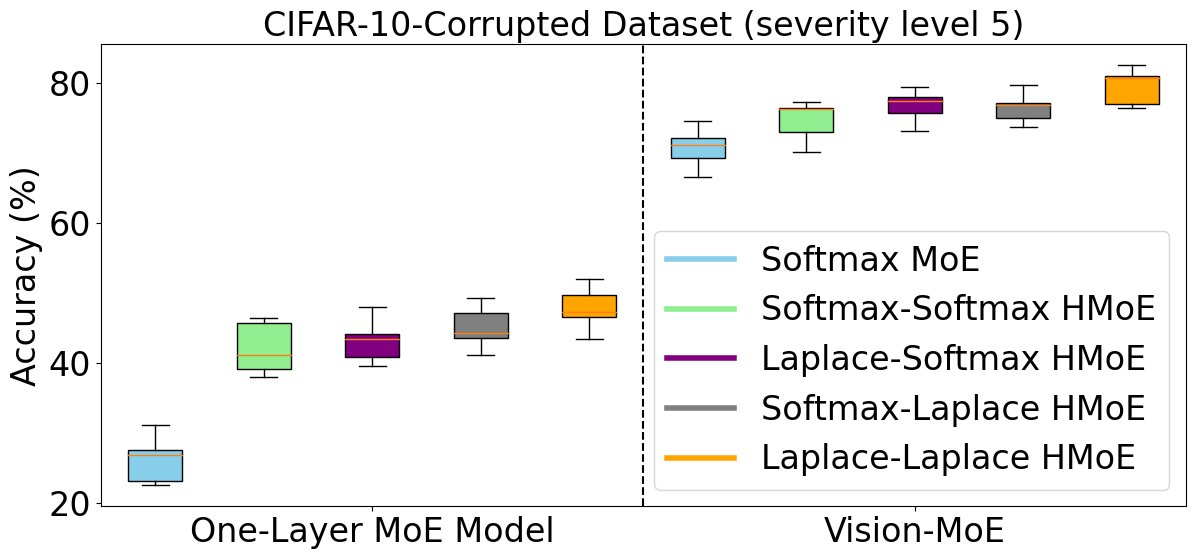

In [22]:
# Data for One-Layer MoE Model and Vision-MoE
one_layer_moe = {
    'Softmax MoE': [27.63, 23.07, 22.52, 31.14, 26.92],
    'Softmax-Softmax HMoE': [41.22, 45.74, 46.43, 39.21, 38.02],
    'Laplace-Softmax HMoE': [43.43, 44.14, 40.88, 39.57, 48.06],
    'Softmax-Laplace HMoE': [47.19, 44.33, 43.56, 41.18, 49.24],
    'Laplace-Laplace HMoE': [49.71, 43.39, 52.08, 46.59, 47.28]
}

vision_moe = {
    'Softmax MoE': [66.63, 69.28, 74.58, 71.17, 72.25],
    'Softmax-Softmax HMoE': [76.39, 72.98, 77.27, 70.14, 76.48],
    'Laplace-Softmax HMoE': [77.46, 78.05, 73.14, 75.83, 79.54],
    'Softmax-Laplace HMoE': [77.24, 79.72, 75.11, 73.83, 76.89],
    'Laplace-Laplace HMoE': [77.12, 81.04, 76.54, 80.83, 82.59]
}

# Combine the data for the two groups
data = [
    one_layer_moe['Softmax MoE'], one_layer_moe['Softmax-Softmax HMoE'], one_layer_moe['Laplace-Softmax HMoE'], 
    one_layer_moe['Softmax-Laplace HMoE'], one_layer_moe['Laplace-Laplace HMoE'],
    vision_moe['Softmax MoE'], vision_moe['Softmax-Softmax HMoE'], vision_moe['Laplace-Softmax HMoE'], 
    vision_moe['Softmax-Laplace HMoE'], vision_moe['Laplace-Laplace HMoE']
]

# Boxplot configuration
fig, ax = plt.subplots(figsize=(14, 6))

box = ax.boxplot(
    data, 
    patch_artist=True,
    labels=[
        'One-Layer MoE Model', 'One-Layer MoE Model', 'One-Layer MoE Model', 
        'One-Layer MoE Model', 'One-Layer MoE Model',
        'Vision-MoE', 'Vision-MoE', 'Vision-MoE', 
        'Vision-MoE', 'Vision-MoE'
    ]
)

# Define colors for the box plot
colors = ['skyblue', 'lightgreen', 'purple', 'gray', 'orange'] * 2

# Apply colors to the box plot
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Add a vertical dashed line to separate the two groups
ax.axvline(x=5.5, color='black', linestyle='--')

# Set y-axis label and title for the figure
ax.set_ylabel('Accuracy (%)', fontsize=24)
ax.set_title('CIFAR-10-Corrupted Dataset (severity level 5)', fontsize=24)

# Customize tick sizes
ax.tick_params(axis='x', labelsize=24)
ax.tick_params(axis='y', labelsize=24)

# Adjust x-ticks and set labels for each group
ax.set_xticks([3, 8])
ax.set_xticklabels(['One-Layer MoE Model', 'Vision-MoE'], fontsize=24)

# Add legend with specified font size
handles = [
    plt.Line2D([0], [0], color='skyblue', lw=4),
    plt.Line2D([0], [0], color='lightgreen', lw=4),
    plt.Line2D([0], [0], color='purple', lw=4),
    plt.Line2D([0], [0], color='gray', lw=4),
    plt.Line2D([0], [0], color='orange', lw=4)
]
ax.legend(handles, ['Softmax MoE', 'Softmax-Softmax HMoE', 'Laplace-Softmax HMoE', 'Softmax-Laplace HMoE', 'Laplace-Laplace HMoE'], 
          loc='lower right', fontsize=24)

# Display the plot
plt.show()

| Task    | Metric            | Softmax          | Sigmoid          |
|---------|-------------------|------------------|------------------|
| 48‑IHM  | AUC (%)           | 79.69 ± 2.11     | **80.34 ± 1.89** |
|         | F1 (%)            | 43.09 ± 4.00     | **45.34 ± 3.95** |
| LOS     | AUC (%)           | 81.82 ± 0.33     | **81.83 ± 0.33** |
|         | F1 (%)            | 73.47 ± 0.74     | **73.69 ± 0.43** |
| PHE     | weighted AUC (%)  | **71.36 ± 0.22** | 71.26 ± 0.41     |
|         | macro‑F1 (%)      | 32.40 ± 0.90     | **32.60 ± 0.91** |

| Task    | Metric            | Softmax + temp   | Sigmoid + temp   | Sigmoid (Euclidean) + temp |
|---------|-------------------|------------------|------------------|----------------------------|
| 48‑IHM  | AUC (%)           | 79.58 ± 2.07     | 80.19 ± 1.64     | **80.27 ± 1.74**           |
|         | F1 (%)            | 44.05 ± 4.10     | 44.65 ± 2.65     | **47.05 ± 3.64**           |
| LOS     | AUC (%)           | 81.81 ± 0.16     | 81.83 ± 0.37     | **81.84 ± 0.31**           |
|         | F1 (%)            | 73.26 ± 0.56     | 73.54 ± 0.80     | **73.80 ± 0.49**           |
| PHE     | weighted AUC (%)  | **71.29 ± 0.46** | 71.14 ± 0.12     | 71.27 ± 0.20               |
|         | macro‑F1 (%)      | 32.49 ± 1.32     | 32.21 ± 0.89     | **32.86 ± 1.08**           |

$$
\begin{align*}
M_{0,0}^* &= \begin{bmatrix} 2.0 & 0.0 & 0.0 \\ 0.0 & 0.5 & 0.0 \\ 0.0 & 0.0 & 1.0 \end{bmatrix}, \quad
M_{0,1}^* = \begin{bmatrix} 0.5 & 0.0 & 0.1 \\ 0.0 & 2.0 & 0.0 \\ 0.1 & 0.0 & 0.8 \end{bmatrix}, \quad
M_{0,2}^* = \begin{bmatrix} 1.0 & 0.2 & 0.0 \\ 0.2 & 0.5 & 0.0 \\ 0.0 & 0.0 & 1.5 \end{bmatrix}, \\
M_{1,0}^* &= \begin{bmatrix} 1.5 & 0.2 & 0.1 \\ 0.2 & 0.3 & 0.0 \\ 0.1 & 0.0 & 0.8 \end{bmatrix}, \quad
M_{1,1}^* = \begin{bmatrix} 0.3 & -0.1 & 0.0 \\ -0.1 & 1.2 & 0.1 \\ 0.0 & 0.1 & 0.5 \end{bmatrix}, \quad
M_{1,2}^* = \begin{bmatrix} 1.0 & 0.0 & 0.2 \\ 0.0 & 0.8 & 0.0 \\ 0.2 & 0.0 & 0.6 \end{bmatrix}, \\
M_{2,0}^* &= \begin{bmatrix} 0.9 & 0.1 & 0.0 \\ 0.1 & 0.6 & 0.2 \\ 0.0 & 0.2 & 1.1 \end{bmatrix}, \quad
M_{2,1}^* = \begin{bmatrix} 1.2 & 0.0 & -0.1 \\ 0.0 & 0.4 & 0.0 \\ -0.1 & 0.0 & 0.7 \end{bmatrix}, \quad
M_{2,2}^* = \begin{bmatrix} 0.5 & 0.3 & 0.0 \\ 0.3 & 1.0 & 0.1 \\ 0.0 & 0.1 & 0.8 \end{bmatrix}.
\end{align*}
$$

| Head $h$ | Expert $i$ | Channel $k$ | $\omega_{h,k}^*$ | $a_{h,i,k}^*$ |
|----------|------------|-------------|------------------|----------------|
| 0 | 0 | 0 | 1.0 | $(1.0,\ -0.5,\ 0.3)$ |
| 0 | 0 | 1 | 0.5 | $(0.5,\ 0.8,\ -0.2)$ |
| 0 | 0 | 2 | 0.3 | $(-0.3,\ 0.4,\ 0.7)$ |
| 0 | 1 | 0 | 1.0 | $(-1.0,\ 0.8,\ 0.1)$ |
| 0 | 1 | 1 | 0.5 | $(0.2,\ -0.3,\ 0.5)$ |
| 0 | 1 | 2 | 0.3 | $(0.6,\ 0.1,\ -0.4)$ |
| 0 | 2 | 0 | 1.0 | $(0.4,\ -0.6,\ 0.2)$ |
| 0 | 2 | 1 | 0.5 | $(-0.5,\ 0.3,\ 0.8)$ |
| 0 | 2 | 2 | 0.3 | $(0.7,\ -0.2,\ -0.3)$ |
| 1 | 0 | 0 | 0.8 | $(0.6,\ 0.4,\ -0.3)$ |
| 1 | 0 | 1 | 0.3 | $(-0.2,\ 0.5,\ 0.6)$ |
| 1 | 0 | 2 | 0.6 | $(0.3,\ -0.1,\ 0.8)$ |
| 1 | 1 | 0 | 0.8 | $(-0.7,\ -0.2,\ 0.4)$ |
| 1 | 1 | 1 | 0.3 | $(0.3,\ -0.4,\ 0.1)$ |
| 1 | 1 | 2 | 0.6 | $(-0.5,\ 0.6,\ -0.2)$ |
| 1 | 2 | 0 | 0.8 | $(0.5,\ 0.3,\ 0.2)$ |
| 1 | 2 | 1 | 0.3 | $(-0.4,\ 0.7,\ -0.5)$ |
| 1 | 2 | 2 | 0.6 | $(0.8,\ -0.3,\ 0.1)$ |
| 2 | 0 | 0 | 0.4 | $(0.2,\ 0.9,\ -0.4)$ |
| 2 | 0 | 1 | 0.7 | $(-0.6,\ 0.3,\ 0.5)$ |
| 2 | 0 | 2 | 0.2 | $(0.4,\ -0.7,\ 0.2)$ |
| 2 | 1 | 0 | 0.4 | $(-0.3,\ 0.5,\ 0.7)$ |
| 2 | 1 | 1 | 0.7 | $(0.7,\ -0.2,\ -0.4)$ |
| 2 | 1 | 2 | 0.2 | $(-0.1,\ 0.6,\ 0.3)$ |
| 2 | 2 | 0 | 0.4 | $(0.5,\ -0.3,\ 0.6)$ |
| 2 | 2 | 1 | 0.7 | $(-0.2,\ 0.8,\ -0.1)$ |
| 2 | 2 | 2 | 0.2 | $(0.3,\ 0.4,\ -0.7)$ |